**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab VI - Logistic Regression**</font>

# Libraries

In [ ]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
import statsmodels.api as sm

In [ ]:
np.random.seed(1234)

In [ ]:
import scipy.stats as stats

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/_Polimi/StatAppHPC/heart_failure_clinical_records_dataset_smhd.csv')

In [ ]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,bmi
0,75.00,0,582,0,20.73,1,265000.00,1.90,138.39,Male,0,4,True,30.82
1,55.00,0,7861,0,29.02,0,263358.03,1.10,131.90,Male,0,6,True,25.40
2,65.00,0,146,0,26.24,0,162000.00,1.30,143.66,Male,1,7,True,29.45
3,50.00,1,111,0,10.21,0,210000.00,1.90,135.03,Male,0,7,True,36.06
4,65.00,1,160,1,19.33,0,327000.00,2.70,136.08,Female,0,8,True,33.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.00,0,61,1,38.05,1,155000.00,1.10,135.58,Male,1,270,False,25.60
295,55.00,0,1820,0,35.20,0,270000.00,1.20,142.02,Female,0,271,False,29.39
296,45.00,0,2060,1,62.32,0,742000.00,0.80,136.38,Female,0,278,False,20.71
297,45.00,0,2413,0,37.49,0,140000.00,1.40,133.91,Male,1,280,False,27.76


In [ ]:
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure',  'sex',  'smoking',  'DEATH_EVENT']
num_vars = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'bmi', 'time']

# Binary Logistic Regression

We want to build a model to classify patients as dead or survived during follow-up: it's a binary classification task.

We use a logistic regression model, which models the probability of the positive class (death) in the following way, where $x_1, ..., x_p$ are the input variables

$$
P(y = 1 | x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)}}
$$


## Model

In [ ]:
X = df[['age', 'bmi', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'ejection_fraction', 'time']]
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1234)

train_index = X_train.index
test_index = X_test.index

We start using all numerical variables

In [ ]:
len(y_test)

60

In [ ]:
X_train_1 = X_train[num_vars]
X_test_1 = X_test[num_vars]

X_train_1 = sm.add_constant(X_train_1)
X_test_1 = sm.add_constant(X_test_1)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_1).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.375744
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            DEATH_EVENT   No. Observations:                  239
Model:                          Logit   Df Residuals:                      230
Method:                           MLE   Df Model:                            8
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.4051
Time:                        15:18:30   Log-Likelihood:                -89.803
converged:                       True   LL-Null:                       -150.95
Covariance Type:            nonrobust   LLR p-value:                 1.118e-22
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -4.8044      7.317     -0.657      0.511     -19.146

By default statsmodels uses the Newton-Raphson iterative optimization method to maximize the likelihood, but other methods can be specified

Statsmodels compute the pseudo R^2 statistics using the McFadden's definition:

$$pseudo_{R^2} = 1 - \frac{LL}{LL_{Null}}$$

It has values from 0 to 1 and it indicates the goodness of the model, but it's not the primary metric used to evaluate LR models

## Odds Ratios

In a logistic model, the effect of the coefficient is different from a linear regression model. A k-unit increase in $x_j$ increases the risk by a factor of $exp(k \cdot \hat{\beta_j})$. Odds ratios are defined as:

$$
OR_j = exp(\hat{\beta_j})
$$

In [ ]:
coef = logit_model.params
odds_ratios = np.exp(coef)

conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']
conf = np.exp(conf)  # Exponentiate to get ORs' CIs

or_summary = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratios,
    "2.5% CI OR": conf['2.5%'],
    "97.5% CI OR": conf['97.5%']
})

print(or_summary)

                          Coefficient  Odds Ratio  2.5% CI OR  97.5% CI OR
age                              0.05        1.05        1.02         1.09
creatinine_phosphokinase         0.00        1.00        1.00         1.00
ejection_fraction               -0.05        0.95        0.91         0.99
platelets                       -0.00        1.00        1.00         1.00
serum_creatinine                 0.52        1.69        0.88         3.24
serum_sodium                    -0.01        0.99        0.95         1.03
bmi                              0.07        1.07        0.91         1.27
time                            -0.02        0.98        0.97         0.99


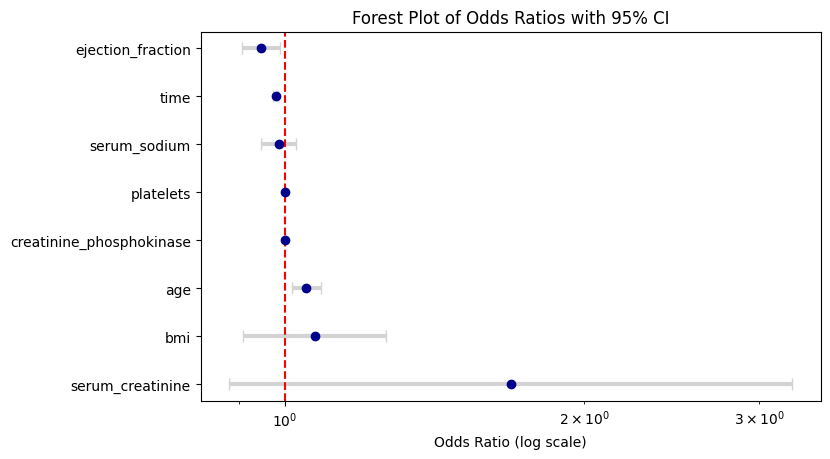

In [ ]:
# Sort by odds ratio for better visualization
or_summary = or_summary.sort_values(by="Odds Ratio", ascending=False)

fig, ax = plt.subplots(figsize=(8, len(or_summary) * 0.6))

# Plot the OR as points
ax.errorbar(or_summary['Odds Ratio'], or_summary.index,
            xerr=[or_summary['Odds Ratio'] - or_summary['2.5% CI OR'], or_summary['97.5% CI OR'] - or_summary['Odds Ratio']],
            fmt='o', color='darkblue', ecolor='lightgray', elinewidth=3, capsize=4)

# Add a vertical line at OR = 1 (no effect)
ax.axvline(1, color='red', linestyle='--')

ax.set_xlabel("Odds Ratio (log scale)")
ax.set_title("Forest Plot of Odds Ratios with 95% CI")
ax.set_xscale("log")  # Log scale for better visualization

plt.show()

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_test_pred_prob = logit_model.predict(X_test_1)

In [ ]:
y_test_pred_prob

,0
73,0.28
110,0.27
291,0.02
168,0.17
289,0.03
124,0.81
286,0.03
164,0.29
296,0.00
261,0.01


In [ ]:
# Convert probabilities to binary outcomes based on a threshold
threshold = 0.5
y_test_pred_class = (y_test_pred_prob > threshold).astype(int)

In [ ]:
y_test_pred_class

,0
73,0
110,0
291,0
168,0
289,0
124,1
286,0
164,0
296,0
261,0


In [ ]:
print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_test_pred_class))

Confusion Matrix on Test Set:
[[39  3]
 [ 7 11]]


With a more nice visualization:

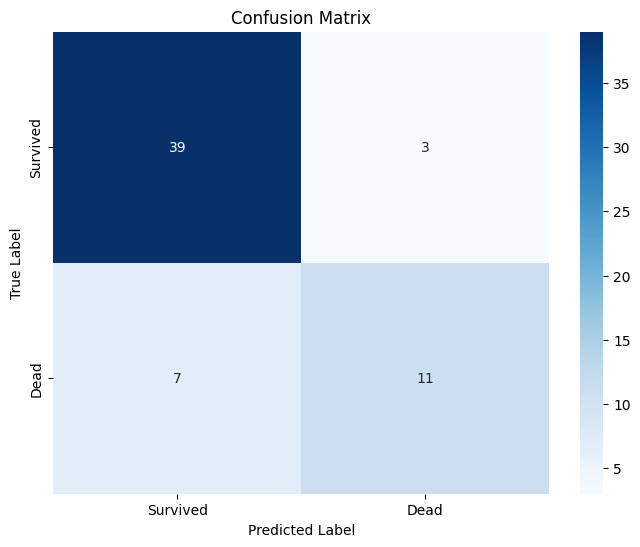

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_class)

class_names = ['Survived', 'Dead']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

[  TN    FP  
   FN    TP]

## AUROC

The Receiver-Operating-Characteristic Curve (ROC Curve) plots the FPR vs TPR at varying the classification threshold from 0 to 1, where

$$TPR = \frac{TP}{TP+FN} (= Sensitivity = Recall)$$

$$FPR = \frac{FP}{FP+TN}$$

The ideal point is (0,1), which maximizes the TPR and minimizes the FPR

The Area Under the Receiver Operating Characteristic Curve (AUROC or simply AUC) is a measure of goodness of the model that is not influences by the choice of a classification threshold

Let's first compute the TPR and FPR from the current confusion matrix, i.e. with threshold=0.5. We will use them later to compare

In [ ]:
tn, fp, fn, tp = cm.ravel()
tpr_original = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr_original = fp / (fp + tn) if (fp + tn) > 0 else 0.0
print(f'FPR={fpr_original}, TPR={tpr_original}')

FPR=0.07142857142857142, TPR=0.6111111111111112


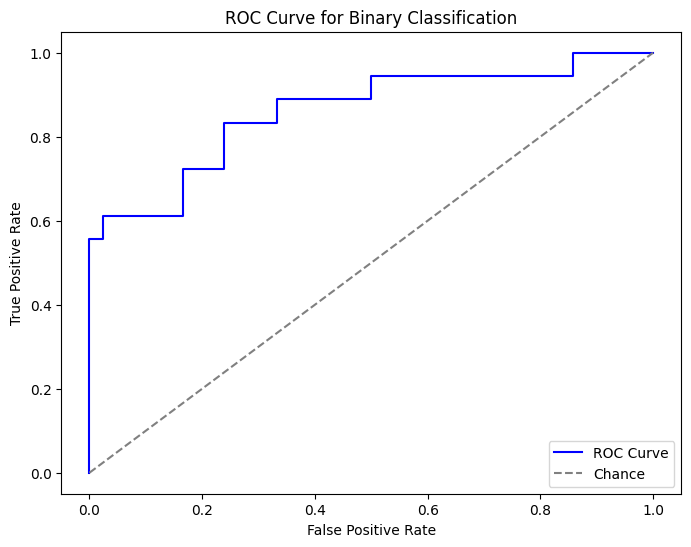

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_pred_prob)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve")

# Plot the diagonal line representing random chance
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binary Classification")
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")

ROC-AUC Score on Test Set: 0.8597883597883599


## Accuracy, Precision, Recall/Sensitivity, F1-Score, Specificity

$$Accuracy = \frac{TP+TN}{TP+FP+TN+FN}$$
$$Precision = \frac{TP}{TP+FP}$$
$$Recall = Sensitivity = \frac{TP}{TP+FN}$$
$$\text{F1-Score} = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$
$$Specificity = \frac{TN}{TN+FP}$$

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred_class, target_names=['Survived', 'Dead'], digits=4))


Classification Report on Test Set:
              precision    recall  f1-score   support

    Survived     0.8478    0.9286    0.8864        42
        Dead     0.7857    0.6111    0.6875        18

    accuracy                         0.8333        60
   macro avg     0.8168    0.7698    0.7869        60
weighted avg     0.8292    0.8333    0.8267        60



In [ ]:
## Try to compute the specificity from the confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print(f"Specificity on Test Set: {specificity}") # It is the recall of class that we defined as negative (Survived)

Specificity on Test Set: 0.9285714285714286


## Choice of the threshold

Using 0.5 as threshold is the most common choice, but it might not be the optimal one, especially in case of class unbalance

One suggest value is the percentage of negative samples

In [ ]:
candidate_threshold_1 = 1 - df['DEATH_EVENT'].mean() # 1 - % of positive samples

In [ ]:
candidate_threshold_1

np.float64(0.6789297658862876)

In [ ]:
y_test_pred_class = (y_test_pred_prob > candidate_threshold_1).astype(int)

print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_test_pred_class))

Confusion Matrix on Test Set:
[[42  0]
 [ 9  9]]


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_class).ravel()

tpr_1 = tp / (tp + fn)  # Sensitivity or Recall or TPR
fpr_1 = fp / (fp + tn)  # False Positive Rate (FPR)

In [ ]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred_class, target_names=['Survived', 'Dead'], digits=4))


Classification Report on Test Set:
              precision    recall  f1-score   support

    Survived     0.8235    1.0000    0.9032        42
        Dead     1.0000    0.5000    0.6667        18

    accuracy                         0.8500        60
   macro avg     0.9118    0.7500    0.7849        60
weighted avg     0.8765    0.8500    0.8323        60



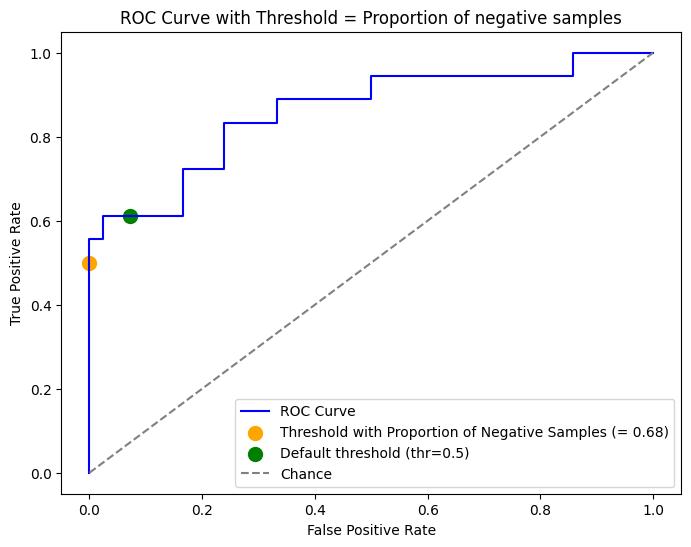

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve")

# Plot the point corresponding to the candidate threshold point
plt.scatter(fpr_1, tpr_1, color='orange', s=100, label=f"Threshold with Proportion of Negative Samples (= {candidate_threshold_1:.2f})")

# Plot the point corresponding to the original threshold point
plt.scatter(fpr_original, tpr_original, color='green', s=100, label=f"Default threshold (thr=0.5)")

# Plot the diagonal line representing random chance
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold = Proportion of negative samples")
plt.legend(loc="lower right")
plt.show()

Another heuristic is the maximization of the Youden's J index, which is the difference between TPR and FPR

In [ ]:
fpr, tpr, thresholds= roc_curve(y_test, y_test_pred_prob)

In [ ]:
fpr

array([0.        , 0.        , 0.        , 0.02380952, 0.02380952,
       0.16666667, 0.16666667, 0.23809524, 0.23809524, 0.33333333,
       0.33333333, 0.5       , 0.5       , 0.85714286, 0.85714286,
       1.        ])

In [ ]:
tpr

array([0.        , 0.05555556, 0.55555556, 0.55555556, 0.61111111,
       0.61111111, 0.72222222, 0.72222222, 0.83333333, 0.83333333,
       0.88888889, 0.88888889, 0.94444444, 0.94444444, 1.        ,
       1.        ])

In [ ]:
thresholds

array([           inf, 9.53908076e-01, 6.76273712e-01, 5.93853823e-01,
       5.77516053e-01, 3.24850371e-01, 2.85982628e-01, 2.73123438e-01,
       2.57326703e-01, 1.66578594e-01, 1.66227879e-01, 7.39754074e-02,
       4.85524201e-02, 1.74947868e-02, 1.38845912e-02, 3.97924223e-04])

In [ ]:
youden_all = tpr - fpr
idx_best = np.argmax(youden_all)
youden_thr = thresholds[idx_best]
best_J = youden_all[idx_best]
youden_tpr, youden_fpr = tpr[idx_best], fpr[idx_best]

print(f"Max Youden's J on ROC: {best_J:.4f} at threshold {youden_thr:.4f} "
      f"(TPR={youden_tpr:.4f}, FPR={youden_fpr:.4f})")

Max Youden's J on ROC: 0.5952 at threshold 0.2573 (TPR=0.8333, FPR=0.2381)


In [ ]:
y_test_pred_class = (y_test_pred_prob > youden_thr).astype(int)

print("Confusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_test_pred_class))

Confusion Matrix on Test Set:
[[32 10]
 [ 4 14]]


In [ ]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred_class, target_names=['Survived', 'Dead'], digits=4))


Classification Report on Test Set:
              precision    recall  f1-score   support

    Survived     0.8889    0.7619    0.8205        42
        Dead     0.5833    0.7778    0.6667        18

    accuracy                         0.7667        60
   macro avg     0.7361    0.7698    0.7436        60
weighted avg     0.7972    0.7667    0.7744        60



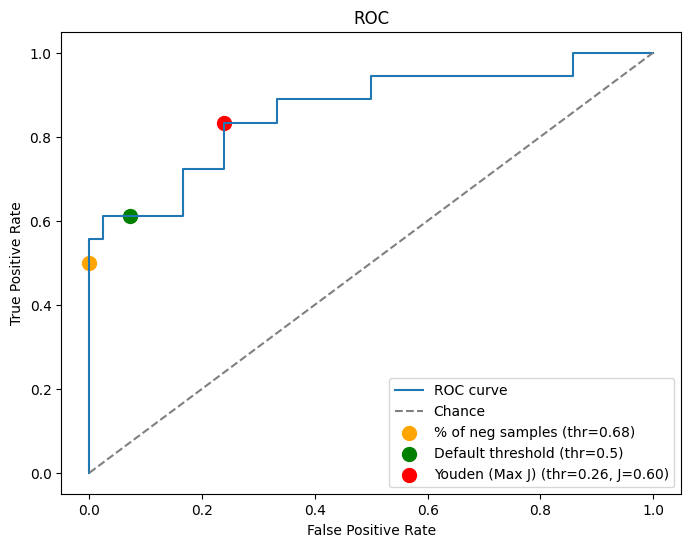

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")

# % of negative points
plt.scatter(fpr_1, tpr_1, s=100, color='orange', label=f"% of neg samples (thr={candidate_threshold_1:.2f})")

# Original threshold point
plt.scatter(fpr_original, tpr_original, color='green', s=100, label=f"Default threshold (thr=0.5)")

# Maximize Youden's J
plt.scatter(youden_fpr, youden_tpr, s=100, color='red',
            label=f"Youden (Max J) (thr={youden_thr:.2f}, J={best_J:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend(loc="lower right")
plt.show()

## Interaction terms

Similary to linear regression, in logistic regression an interaction means that the effect of one predictor depends on the value of another predictor.

Here we study whether the association between age and death differs between patients with and without diabetes.

We build a smaller interpretable model:
$$logit(P(DEATH\_EVENT = 1)) = \beta_0 + \beta_1 \cdot ejection\_fraction + \beta_2 \cdot diabetes + \beta_3 \cdot ejection\_fraction \cdot diabetes $$


In [ ]:
num_var = 'ejection_fraction'
cat_var = 'diabetes'

X_int = X_train[[num_var, cat_var]].copy()
X_int['interaction'] = X_int[num_var] * X_int[cat_var]

X_int = sm.add_constant(X_int)

logit_interaction = sm.Logit(y_train, X_int).fit()

print(logit_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.600172
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            DEATH_EVENT   No. Observations:                  239
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            3
Date:                Fri, 08 May 2026   Pseudo R-squ.:                 0.04972
Time:                        09:29:47   Log-Likelihood:                -143.44
converged:                       True   LL-Null:                       -150.95
Covariance Type:            nonrobust   LLR p-value:                  0.001809
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.4277      0.633      2.256      0.024       0.187       2.668
ejection

In [ ]:
coef_int = logit_interaction.params
or_int = np.exp(coef_int)

conf_int = logit_interaction.conf_int()
conf_int.columns = ['2.5%', '97.5%']
conf_int_or = np.exp(conf_int)

or_summary_int = pd.DataFrame({
    'Coefficient': coef_int,
    'Odds Ratio': or_int,
    '2.5% CI OR': conf_int_or['2.5%'],
    '97.5% CI OR': conf_int_or['97.5%']
})

or_summary_int

,Coefficient,Odds Ratio,2.5% CI OR,97.5% CI OR
const,1.43,4.17,1.21,14.42
ejection_fraction,-0.06,0.94,0.91,0.98
diabetes,-1.36,0.26,0.04,1.81
interaction,0.04,1.04,0.98,1.09


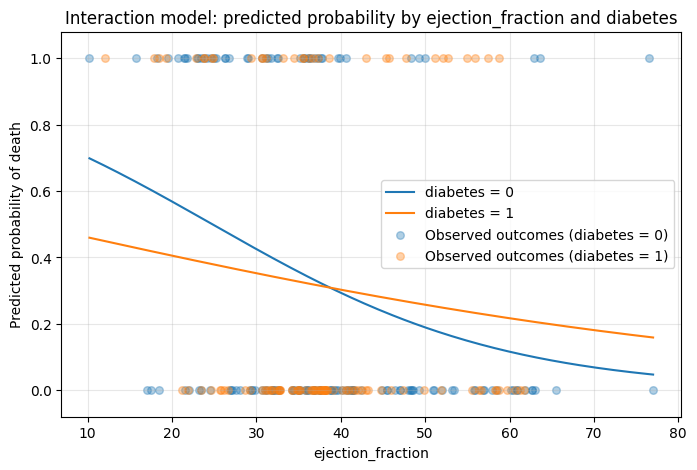

In [ ]:
# ============================================================
# Plot predicted probabilities by numerical variable and category
# ============================================================

ef_grid = np.linspace(X_train[num_var].min(), X_train[num_var].max(), 200)

plot_df_0 = pd.DataFrame({
    'const': 1.0,
    num_var: ef_grid,
    cat_var: 0,
    'interaction': ef_grid * 0
})

plot_df_1 = pd.DataFrame({
    'const': 1.0,
    num_var: ef_grid,
    cat_var: 1,
    'interaction': ef_grid * 1
})

p_cat_0 = logit_interaction.predict(plot_df_0)
p_cat_1 = logit_interaction.predict(plot_df_1)

plt.figure(figsize=(8, 5))

# Predicted probability curves
plt.plot(ef_grid, p_cat_0, label=f'{cat_var} = 0')
plt.plot(ef_grid, p_cat_1, label=f'{cat_var} = 1')

# Masks for observed points
mask_cat_0 = X_train[cat_var] == 0
mask_cat_1 = X_train[cat_var] == 1

# Observed outcomes, colored by category
plt.scatter(
    X_train.loc[mask_cat_0, num_var],
    y_train[mask_cat_0],
    alpha=0.35,
    s=30,
    label=f'Observed outcomes ({cat_var} = 0)'
)

plt.scatter(
    X_train.loc[mask_cat_1, num_var],
    y_train[mask_cat_1],
    alpha=0.35,
    s=30,
    label=f'Observed outcomes ({cat_var} = 1)'
)

plt.xlabel(num_var)
plt.ylabel('Predicted probability of death')
plt.title(f'Interaction model: predicted probability by {num_var} and {cat_var}')

plt.ylim(-0.08, 1.08)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# Comparing models with and without interaction
# ============================================================

X_main = X_train[[num_var, cat_var]].copy()
X_main = sm.add_constant(X_main)

logit_main = sm.Logit(y_train, X_main).fit()

print("Model without interaction")
print(logit_main.summary())

print("\nModel with interaction")
print(logit_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.603882
         Iterations 5
Model without interaction
                           Logit Regression Results                           
Dep. Variable:            DEATH_EVENT   No. Observations:                  239
Model:                          Logit   Df Residuals:                      236
Method:                           MLE   Df Model:                            2
Date:                Fri, 08 May 2026   Pseudo R-squ.:                 0.04384
Time:                        09:33:12   Log-Likelihood:                -144.33
converged:                       True   LL-Null:                       -150.95
Covariance Type:            nonrobust   LLR p-value:                  0.001337
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9373      0.494      1.897      0.058      -

Homework: what if you add polynomial terms?

# Multiclass logistic regression

We want to develop a model to classify HF patients in three ejection fraction classes

In [ ]:
df['ef_cat'] = pd.cut(df['ejection_fraction'], bins=[0,40,50, 100], labels=['reduced', 'mildly reduced', 'preserved'])

In [ ]:
df[['ejection_fraction', 'ef_cat']]

,ejection_fraction,ef_cat
0,20.73,reduced
1,29.02,reduced
2,26.24,reduced
3,10.21,reduced
4,19.33,reduced
...,...,...
294,38.05,reduced
295,35.20,reduced
296,62.32,preserved
297,37.49,reduced


## Model

A multinomial logistic regression models a multiclass classification task. With $K$ classes, it assumes a baseline class (assume the $K$-th without loss of generality) and computes a set of coefficients for each other class $k$:

$$
P(y = k | x) = \frac{e^{\beta_{k0} + \beta_{k1} x_1 + \beta_{k2} x_2 + \dots + \beta_{kp} x_p}}{1 + \sum_{j=1}^{K-1} e^{\beta_{j0} + \beta_{j1} x_1 + \beta_{j2} x_2 + \dots + \beta_{jp} x_p}} \quad\text{for }k < K \\
P(y = K | x) = \frac{1}{1 + \sum_{j=1}^{K-1} e^{\beta_{j0} + \beta_{j1} x_1 + \beta_{j2} x_2 + \dots + \beta_{jp} x_p}} = 1 - \sum_{k=1}^{K-1} P(y = k | x)
$$

Remember that here

$$
\log\left(
\frac{P(y = k \mid x)}
     {P(y = K \mid x)}
\right)
=
\beta_{k0}
+
\beta_{k1}x_1
+
\beta_{k2}x_2
+
\dots
+
\beta_{kp}x_p
\qquad \text{for } k = 1, \dots, K-1
$$

so the OR are to be intepreted wrt the reference class K

The multinomial logistic regression model implemented in the *statsmodels* library requires categorical input variables to be *one-hot encoded*

In [ ]:
df_encoded = pd.get_dummies(df, columns=cat_vars, drop_first=True, dtype=int) # another way to apply one-hot encoding

In [ ]:
df_encoded

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,bmi,ef_cat,anaemia_1,diabetes_1,high_blood_pressure_1,sex_Male,smoking_1,DEATH_EVENT_True
0,75.00,582,20.73,265000.00,1.90,138.39,4,30.82,reduced,0,0,1,1,0,1
1,55.00,7861,29.02,263358.03,1.10,131.90,6,25.40,reduced,0,0,0,1,0,1
2,65.00,146,26.24,162000.00,1.30,143.66,7,29.45,reduced,0,0,0,1,1,1
3,50.00,111,10.21,210000.00,1.90,135.03,7,36.06,reduced,1,0,0,1,0,1
4,65.00,160,19.33,327000.00,2.70,136.08,8,33.69,reduced,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.00,61,38.05,155000.00,1.10,135.58,270,25.60,reduced,0,1,1,1,1,0
295,55.00,1820,35.20,270000.00,1.20,142.02,271,29.39,reduced,0,0,0,0,0,0
296,45.00,2060,62.32,742000.00,0.80,136.38,278,20.71,preserved,0,1,0,0,0,0
297,45.00,2413,37.49,140000.00,1.40,133.91,280,27.76,reduced,0,0,0,1,1,0


In [ ]:
# fit the model
X = df_encoded[['age', 'bmi', 'serum_sodium', 'serum_creatinine', 'diabetes_1', 'sex_Male', 'smoking_1', 'high_blood_pressure_1', 'anaemia_1']]
y = df_encoded['ef_cat']  # Multiclass target variable

X = sm.add_constant(X)

#STRATIFICATION WITH RESPECT TO THE TARGET CLASS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y)

model = sm.MNLogit(y_train, X_train)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.625371
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                 ef_cat   No. Observations:                  239
Model:                        MNLogit   Df Residuals:                      219
Method:                           MLE   Df Model:                           18
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.2901
Time:                        09:46:05   Log-Likelihood:                -149.46
converged:                       True   LL-Null:                       -210.53
Covariance Type:            nonrobust   LLR p-value:                 1.657e-17
ef_cat=mildly reduced       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    16.5763      6.723      2.466      0.014       3.400      29.

In [ ]:
result.params

,0,1
const,16.58,24.42
age,0.02,-0.00
bmi,-0.34,-0.89
serum_sodium,-0.09,-0.05
serum_creatinine,1.15,2.51
diabetes_1,-0.09,0.60
sex_Male,0.46,-0.06
smoking_1,-0.36,0.35
high_blood_pressure_1,-0.05,-0.31
anaemia_1,-0.50,0.31


In [ ]:
ynames_map = model._ynames_map

print(ynames_map)

{0: 'reduced', 1: 'mildly reduced', 2: 'preserved'}


In [ ]:
# Sort by original class index
ordered_classes = [ynames_map[k] for k in sorted(ynames_map.keys())]

# In MNLogit, the FIRST class is the reference/baseline
baseline_class = ordered_classes[0]

# Remaining classes correspond to result.params columns
non_baseline_classes = ordered_classes[1:]

# Build mapping:
# result.params columns -> actual class names
column_mapping = {
    col: cls_name
    for col, cls_name in zip(result.params.columns, non_baseline_classes)
}

print(column_mapping)

# Rename params
result.params = result.params.rename(columns=column_mapping)

{0: 'mildly reduced', 1: 'preserved'}


In [ ]:
result.params

,mildly reduced,preserved
const,16.58,24.42
age,0.02,-0.00
bmi,-0.34,-0.89
serum_sodium,-0.09,-0.05
serum_creatinine,1.15,2.51
diabetes_1,-0.09,0.60
sex_Male,0.46,-0.06
smoking_1,-0.36,0.35
high_blood_pressure_1,-0.05,-0.31
anaemia_1,-0.50,0.31


In [ ]:
np.exp(result.params)

,mildly reduced,preserved
const,15812631.77,40511846878.96
age,1.02,1.00
bmi,0.71,0.41
serum_sodium,0.92,0.95
serum_creatinine,3.16,12.32
diabetes_1,0.92,1.83
sex_Male,1.59,0.94
smoking_1,0.70,1.42
high_blood_pressure_1,0.96,0.74
anaemia_1,0.61,1.37


Example of interpretation of OR for multinomial LR:

For a one-unit increase in serum creatinine the odds of being in the mildly reduced EF group **rather than the reduced EF group** (baseline class) are multiplied by about 3.16, holding all other predictors fixed.

In [ ]:
## Plot the odds ratios for both classes for which parameters were estimated

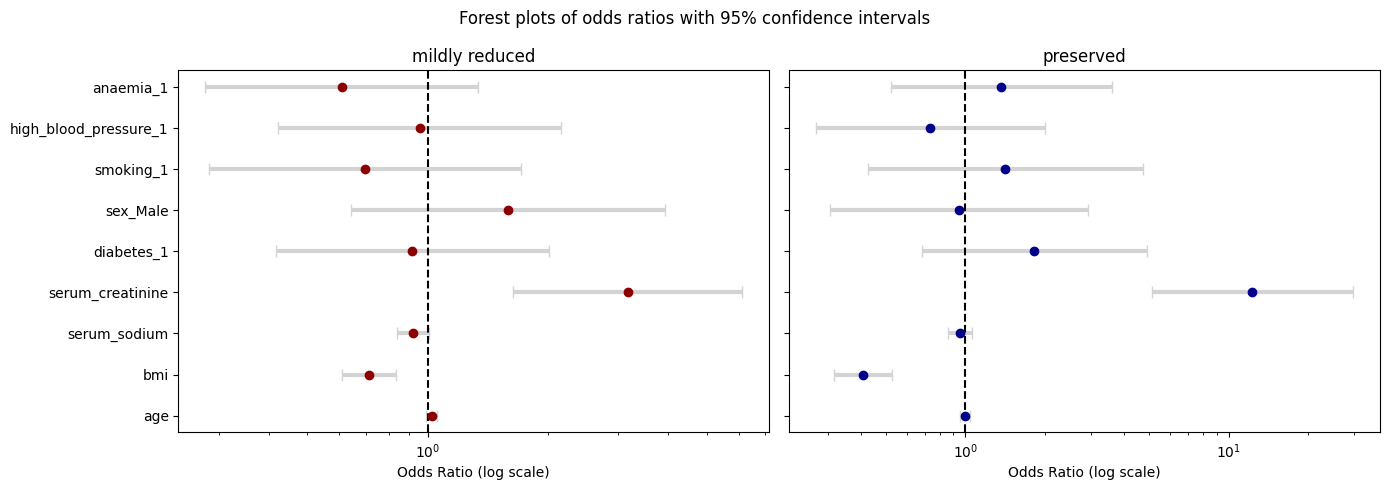

In [ ]:
# Extract coefficients / ORs

ci = result.conf_int()
ci.columns = ["2.5%", "97.5%"]

classes = result.params.columns

summaries = {}

for cls in classes:
    coef = result.params[cls]
    or_values = np.exp(coef)

    conf = ci.loc[cls]
    conf_or = np.exp(conf)

    summaries[cls] = pd.DataFrame({
        "Coefficient": coef,
        "Odds Ratio": or_values,
        "2.5% CI": conf_or["2.5%"],
        "97.5% CI": conf_or["97.5%"]
    })

summaries = {
    cls: summaries[cls].drop(index="const", errors="ignore")
    for cls in classes
}

predictor_names = summaries[classes[0]].index

fig, axes = plt.subplots(
    1, len(classes),
    figsize=(7 * len(classes), len(predictor_names) * 0.55),
    sharey=True
)

if len(classes) == 1:
    axes = [axes]

colors = ["darkred", "darkblue"]

for ax, cls, color in zip(axes, classes, colors):
    summary = summaries[cls]

    y_pos = np.arange(len(summary))

    ax.errorbar(
        summary["Odds Ratio"],
        y_pos,
        xerr=[
            summary["Odds Ratio"] - summary["2.5% CI"],
            summary["97.5% CI"] - summary["Odds Ratio"]
        ],
        fmt="o",
        color=color,
        ecolor="lightgray",
        elinewidth=3,
        capsize=4
    )

    ax.axvline(1, color="black", linestyle="--")
    ax.set_xscale("log")
    ax.set_title(str(cls))
    ax.set_xlabel("Odds Ratio (log scale)")

axes[0].set_yticks(np.arange(len(predictor_names)))
axes[0].set_yticklabels(predictor_names)

plt.suptitle("Forest plots of odds ratios with 95% confidence intervals")
plt.tight_layout()
plt.show()

## Test set evaluation

In [ ]:
y_test_pred_prob = result.predict(X_test)  # Returns probabilities for each class
y_test_pred_prob

,0,1,2
170,0.95,0.04,0.01
237,0.89,0.10,0.01
218,0.88,0.10,0.01
228,0.88,0.12,0.00
264,0.19,0.25,0.55
129,0.46,0.23,0.31
97,0.12,0.12,0.77
139,0.77,0.18,0.05
193,0.92,0.07,0.00
39,0.91,0.08,0.01


In [ ]:
y_test_pred_prob.rename(model._ynames_map, axis='columns', inplace=True)

#for each sample, assign the class with maximum probability
y_test_pred_class = y_test_pred_prob.idxmax(axis=1)

example of the output on a single point

In [ ]:
print('Predicted probabilities:')
print(y_test_pred_prob.iloc[0])
print('\n\nPredicted class:')
print(y_test_pred_class.iloc[0])

Predicted probabilities:
reduced          0.95
mildly reduced   0.04
preserved        0.01
Name: 170, dtype: float64


Predicted class:
reduced


In [ ]:
y_test

,ef_cat
170,reduced
237,reduced
218,reduced
228,reduced
264,mildly reduced
129,mildly reduced
97,preserved
139,reduced
193,reduced
39,reduced


In [ ]:
y_test_pred_class

,0
170,reduced
237,reduced
218,reduced
228,reduced
264,preserved
129,reduced
97,preserved
139,reduced
193,reduced
39,reduced


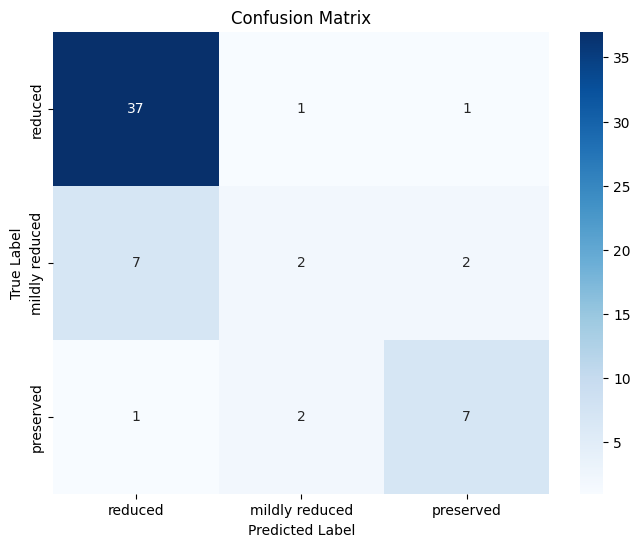

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_class, labels=list(model._ynames_map.values()))

class_names = model._ynames_map.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_class))


Classification Report:
                precision    recall  f1-score   support

mildly reduced       0.40      0.18      0.25        11
     preserved       0.70      0.70      0.70        10
       reduced       0.82      0.95      0.88        39

      accuracy                           0.77        60
     macro avg       0.64      0.61      0.61        60
  weighted avg       0.72      0.77      0.74        60



In a multiclass context, the ROC-AUC can be computed per class with a one-vs-all approach

In [ ]:
# Compute ROC AUC for each class (one-vs-all)
roc_auc_scores = {}
for i in (y_test_pred_prob.columns):
    roc_auc = roc_auc_score(y_test == i, y_test_pred_prob.loc[:, i])  # Treat class i as positive
    roc_auc_scores[i] = roc_auc

# Output the ROC AUC scores
for class_name, auc in roc_auc_scores.items():
    print(f'ROC AUC for {class_name}: {auc:.2f}')

ROC AUC for reduced: 0.93
ROC AUC for mildly reduced: 0.73
ROC AUC for preserved: 0.95


An aggregate ROC-AUC can be computed in different ways

In [ ]:
y_test = y_test.map({'reduced': 0, 'mildly reduced': 1, 'preserved': 2})
y_test_pred_prob.rename(columns={'reduced': 0, 'mildly reduced': 1, 'preserved': 2}, inplace=True)

roc_auc_micro = roc_auc_score(y_test, y_test_pred_prob, average='micro', multi_class='ovr')
print(f'Micro-average ROC AUC: {roc_auc_micro:.2f}')

roc_auc_micro = roc_auc_score(y_test, y_test_pred_prob, average='macro', multi_class='ovr')
print(f'Macro-average ROC AUC: {roc_auc_micro:.2f}')

roc_auc_micro = roc_auc_score(y_test, y_test_pred_prob, average='weighted', multi_class='ovr')
print(f'Weighted-average ROC AUC: {roc_auc_micro:.2f}')

Micro-average ROC AUC: 0.92
Macro-average ROC AUC: 0.87
Weighted-average ROC AUC: 0.89


\begin{array}{|c|c|c|c|}
\hline
\textbf{Aspect} & \textbf{Macro-Averaging} & \textbf{Micro-Averaging} & \textbf{Weighted Averaging} \\
\hline
\textbf{Calculation} & \text{Average of individual class metrics} & \text{Aggregated metrics across all classes} & \text{Average of class metrics weighted by class size} \\
\hline
\textbf{Class Weighting} & \text{Treats all classes equally} & \text{Larger classes have more influence} & \text{Larger classes influence the average more} \\
\hline
\textbf{Performance Insight} & \text{Insight into performance of each class} & \text{Overall performance across the entire dataset} & \text{Balanced evaluation considering class sizes} \\
\hline
\textbf{Sensitivity} & \text{Sensitive to class imbalance} & \text{More robust to class imbalance} & \text{Moderately sensitive to class imbalance} \\
\hline
\textbf{Use Cases} & \text{Class-specific performance} & \text{Overall model performance} & \text{Balanced performance in imbalanced datasets} \\
\hline
\end{array}


$$
\text{Precision}_{\text{micro}} = \frac{\sum_{i=1}^{C} \text{TP}_i}{\sum_{i=1}^{C} (\text{TP}_i + \text{FP}_i)}
$$

$$
\text{Recall}_{\text{micro}} = \frac{\sum_{i=1}^{C} \text{TP}_i}{\sum_{i=1}^{C} (\text{TP}_i + \text{FN}_i)}
$$

$$
\text{F1}_{\text{micro}} = 2 \times \frac{\text{Precision}_{\text{micro}} \times \text{Recall}_{\text{micro}}}{\text{Precision}_{\text{micro}} + \text{Recall}_{\text{micro}}}
$$


Use macro when:

*  You care about per-class behavior, and you want to treat all classes equally, regardless of their frequency.

*  You want to evaluate model fairness across all classes, including rare or underrepresented ones.

*  You're dealing with imbalanced data, and you want to make sure small classes still matter in the evaluation.

*  You want to highlight weaknesses in your model’s performance on rare classes.



Use micro when:

*  You don't care about classes individually.

* You only care about total prediction quality.

* You are working with highly multilabel settings (many labels per sample).

* You want one simple number for "How many labels did I guess right?".

Use weighted when:

* You do care about per-class behavior.

* You want a summary that adjusts for imbalance but still thinks per-class.

* You have imbalanced classes, but you still want per-class precision/recall insight.

## Change baseline class

Manually encoding the target variable allows us to change the order of the numerical labels and consequently change the variable used as base

In [ ]:
df_encoded = pd.get_dummies(df, columns=cat_vars, drop_first=True, dtype=int)
df_encoded['ef_cat'] = pd.Categorical(df['ef_cat'], categories=['mildly reduced', 'preserved', 'reduced'], ordered=True)

In [ ]:
X = df_encoded[['age', 'bmi', 'serum_sodium', 'serum_creatinine', 'diabetes_1', 'sex_Male', 'smoking_1', 'high_blood_pressure_1', 'anaemia_1']]
y = df_encoded['ef_cat']  # Multiclass target variable

X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y)

In [ ]:
model = sm.MNLogit(y_train, X_train)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.625371
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                 ef_cat   No. Observations:                  239
Model:                        MNLogit   Df Residuals:                      219
Method:                           MLE   Df Model:                           18
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.2901
Time:                        10:03:22   Log-Likelihood:                -149.46
converged:                       True   LL-Null:                       -210.53
Covariance Type:            nonrobust   LLR p-value:                 1.657e-17
     ef_cat=preserved       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.8485      8.602      0.912      0.362      -9.011      24.

In [ ]:
np.exp(result.params).rename(columns={0: 'preserved OR', 1:'reduced OR'})

,preserved OR,reduced OR
const,2561.99,0.00
age,0.97,0.98
bmi,0.57,1.40
serum_sodium,1.04,1.09
serum_creatinine,3.89,0.32
diabetes_1,2.00,1.09
sex_Male,0.60,0.63
smoking_1,2.03,1.43
high_blood_pressure_1,0.77,1.05
anaemia_1,2.25,1.64


# Residual diagnostics

In logistic regression, residuals are mainly used as diagnostic tools.  
A useful plot is residuals versus a predictor.

If the model is adequate, residuals should fluctuate around zero without a clear systematic pattern.  
A visible curve, trend, or structure may suggest that the model is missing something, such as a nonlinear effect, an interaction, or an omitted predictor.

Here we use deviance residuals, which are commonly used in logistic regression because they are directly connected to the model deviance.

In [ ]:
num_var = 'ejection_fraction'
cat_var = 'diabetes'

X = df[['age', 'bmi', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'ejection_fraction', 'time']]
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1234)


X_int = X_train[[num_var, cat_var]].copy()
X_int['interaction'] = X_int[num_var] * X_int[cat_var]

X_int = sm.add_constant(X_int)

logit_interaction = sm.Logit(y_train, X_int).fit()

print(logit_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.600172
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            DEATH_EVENT   No. Observations:                  239
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            3
Date:                Fri, 08 May 2026   Pseudo R-squ.:                 0.04972
Time:                        10:06:09   Log-Likelihood:                -143.44
converged:                       True   LL-Null:                       -150.95
Covariance Type:            nonrobust   LLR p-value:                  0.001809
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.4277      0.633      2.256      0.024       0.187       2.668
ejection

/tmp/ipykernel_12111/171509743.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')


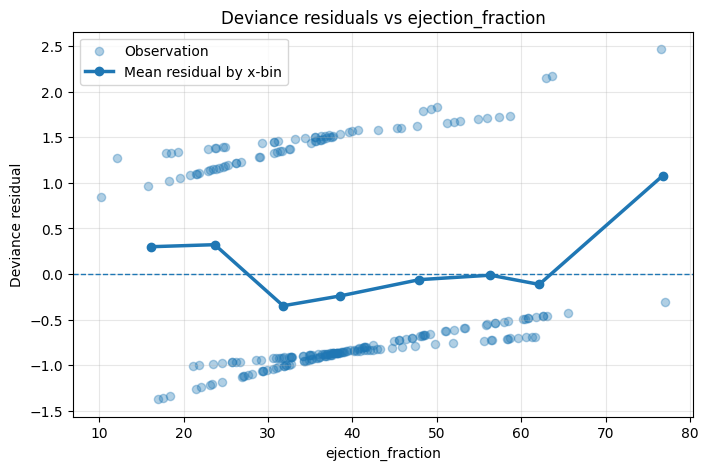

In [ ]:
# ============================================================
# Residual diagnostics with mean residual curve
# ============================================================

resid_dev = logit_interaction.resid_dev

plt.figure(figsize=(8, 5))

# Scatter plot of residuals
plt.scatter(
    X_train[num_var],
    resid_dev,
    alpha=0.35,
    s=35,
    label='Observation'
)

# ------------------------------------------------------------
# Mean residual curve using bins
# ------------------------------------------------------------

tmp_df = pd.DataFrame({
    'x': X_train[num_var],
    'resid': resid_dev
})

# Create bins along the predictor
tmp_df['bin'] = pd.cut(tmp_df['x'], bins=8)

# Mean x and mean residual inside each bin
bin_summary = (
    tmp_df
    .groupby('bin')
    .agg(
        mean_x=('x', 'mean'),
        mean_resid=('resid', 'mean')
    )
    .reset_index(drop=True)
)

# Plot mean residual curve
plt.plot(
    bin_summary['mean_x'],
    bin_summary['mean_resid'],
    marker='o',
    linewidth=2.5,
    label='Mean residual by x-bin'
)

# Horizontal reference line
plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel(num_var)
plt.ylabel('Deviance residual')
plt.title(f'Deviance residuals vs {num_var}')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

Residuals should not highlight a pattern deviating from 0. This is not exactly the case, mostly due to behaviour at the extreme values of ejection fraction

# Influence and Leverage

In [ ]:
# ============================================================
# Influence diagnostics: Cook's distance
# ============================================================

# Cook's distance is a standard influence diagnostic.
# It summarizes how much each observation affects the fitted model,
# combining information from residuals and leverage.

influence = logit_interaction.get_influence()

leverage = influence.hat_matrix_diag
resid_dev = logit_interaction.resid_dev
cooks_d, _ = influence.cooks_distance

influence_df = X_train[[num_var, cat_var]].copy()
influence_df['y'] = y_train
influence_df['pred_prob'] = logit_interaction.predict()
influence_df['deviance_residual'] = resid_dev
influence_df['leverage'] = leverage
influence_df["cooks_distance"] = cooks_d

# Display observations with largest Cook's distance
influence_df.sort_values(
    "cooks_distance",
    ascending=False
).head(10)

,ejection_fraction,diabetes,y,pred_prob,deviance_residual,leverage,cooks_distance
217,76.57,0,True,0.05,2.47,0.03,0.13
8,63.65,0,True,0.10,2.17,0.02,0.06
113,62.95,0,True,0.10,2.15,0.02,0.06
52,58.72,1,True,0.22,1.74,0.04,0.04
44,57.40,1,True,0.23,1.72,0.04,0.03
36,55.94,1,True,0.23,1.71,0.03,0.03
19,54.93,1,True,0.24,1.70,0.03,0.03
59,12.09,1,True,0.45,1.27,0.07,0.03
27,52.74,1,True,0.25,1.68,0.03,0.02
34,52.10,1,True,0.25,1.67,0.03,0.02


/tmp/ipykernel_12111/2438192721.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


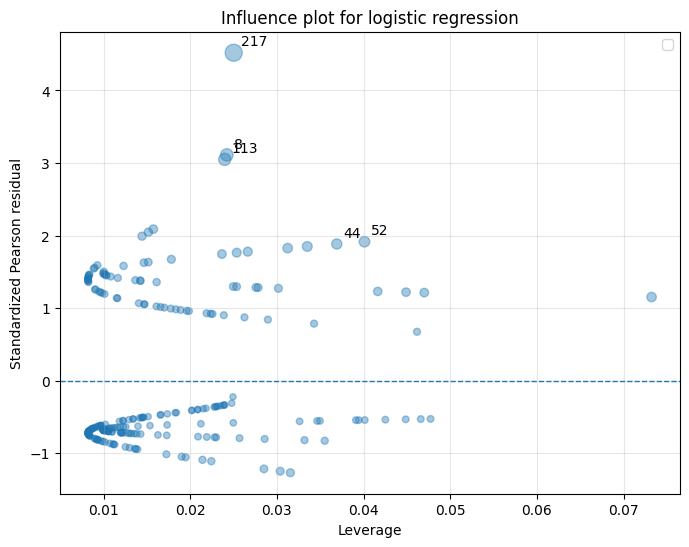

In [ ]:
# ============================================================
# Influence plot
# ============================================================

influence = logit_interaction.get_influence()

leverage = np.asarray(influence.hat_matrix_diag)
cooks_d, _ = influence.cooks_distance
cooks_d = np.asarray(cooks_d)

resid_pearson = np.asarray(logit_interaction.resid_pearson)
standardized_resid = resid_pearson / np.sqrt(1 - leverage)

top_k = 5
top_pos = np.argsort(cooks_d)[-top_k:]

plt.figure(figsize=(8, 6))

plt.scatter(
    leverage,
    standardized_resid,
    s=1000 * cooks_d + 20,
    alpha=0.4,
)

for pos in top_pos:
    plt.annotate(
        str(logit_interaction.model.data.row_labels[pos]),
        xy=(leverage[pos], standardized_resid[pos]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Leverage")
plt.ylabel("Standardized Pearson residual")
plt.title("Influence plot for logistic regression")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

Todo: try to refit the model w/o points 217 (and 8 and 113) and replot the deviance curve

Observations with:
- large residuals but low leverage are poorly fitted but usually have limited influence;
- high leverage but small residuals are unusual but well explained by the model;
- both high leverage and large residuals are the observations most likely to influence the fitted coefficients.

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/6BUxE15mMt) (estimated 2 minutes)